# Zeitreihenanalyse

In diesem Notebook werden verschiedene Zeitreihendatensätze analysiert und miteinander verglichen. Ziel der Analyse ist es, zeitliche Muster, Trends, saisonale Effekte sowie statistische Eigenschaften der Daten zu untersuchen.

Dazu werden drei unterschiedliche Datensätze betrachtet:
- Gold Price Dataset (Goldpreise)
- Apple Stock Dataset (Aktienkurse)
- Weather Dataset (Temperaturdaten)

Die Analyse umfasst die Datenbereinigung, explorative Visualisierung, deskriptive Statistik sowie die Untersuchung zeitlicher Abhängigkeiten mithilfe von Zeitreihenmethoden wie ACF, Stationaritätsanalyse sowie AR-, MA-, ARMA- und ARIMA-Modellen.

## 1. Bibliotheken importieren

Für die Analyse werden Bibliotheken zur Datenverarbeitung, Visualisierung und Modellierung verwendet.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss

## 2. Datensätze laden

Die Datensätze für Amazon Sales, Apple Stock und Wetterdaten werden eingelesen und anschließend überprüft.

In [2]:
gold = pd.read_csv("data/raw/GoldPrice.csv", low_memory=False)
apple   = pd.read_csv("data/raw/apple_stock.csv", header=0, skiprows=[1, 2])
weather = pd.read_csv("data/raw/weather_ts.csv")


## 3. Überblick über die Datensätze

Zur ersten Orientierung werden die Dimensionen und die ersten Zeilen der Datensätze angezeigt.

In [3]:
datasets = {
    "Gold Price": gold,
    "Apple Stock": apple,
    "Weather": weather
}

for name, df in datasets.items():
    print(name)
    print(df.shape)
    display(df.head())
    print("=" * 150)

Gold Price
(2531, 6)


,Date,Price,Open,High,Low,Chg%
0,"Sep 11, 2020",1957.35,1952.55,1963.3,1944.35,-0.0035
1,"Sep 10, 2020",1964.30,1955.30,1975.2,1948.60,0.0048
2,"Sep 09, 2020",1954.90,1939.40,1959.7,1926.30,0.0060
3,"Sep 08, 2020",1943.20,1938.00,1948.3,1911.70,0.0031
4,"Sep 07, 2020",1937.10,1940.70,1947.4,1930.45,-0.0018


Apple Stock
(2596, 6)


,Price,Close,High,Low,Open,Volume
0,2016-01-04,23.730947,23.735454,22.976333,23.113741,270597600
1,2016-01-05,23.136259,23.843569,23.068683,23.821044,223164000
2,2016-01-06,22.683493,23.059675,22.496530,22.651957,273829600
3,2016-01-07,21.726154,22.555105,21.721650,22.228481,324377600
4,2016-01-08,21.841028,22.325334,21.795977,22.199190,283192000


Weather
(420551, 15)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


# 4. Zeitreihenanalyse

### Stil setzen

In [4]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

## Goldpreis im Zeitverlauf

Der wöchentliche Goldpreis zeigt über den gesamten Zeitraum einen langfristigen Aufwärtstrend. Besonders ab 2019 steigt der Goldpreis deutlich an. Kurzfristige Schwankungen sind weiterhin sichtbar, insgesamt entwickelt sich die Zeitreihe jedoch relativ stabil. Die Wochenaggregation reduziert tägliches Rauschen und macht den langfristigen Trend besser erkennbar.

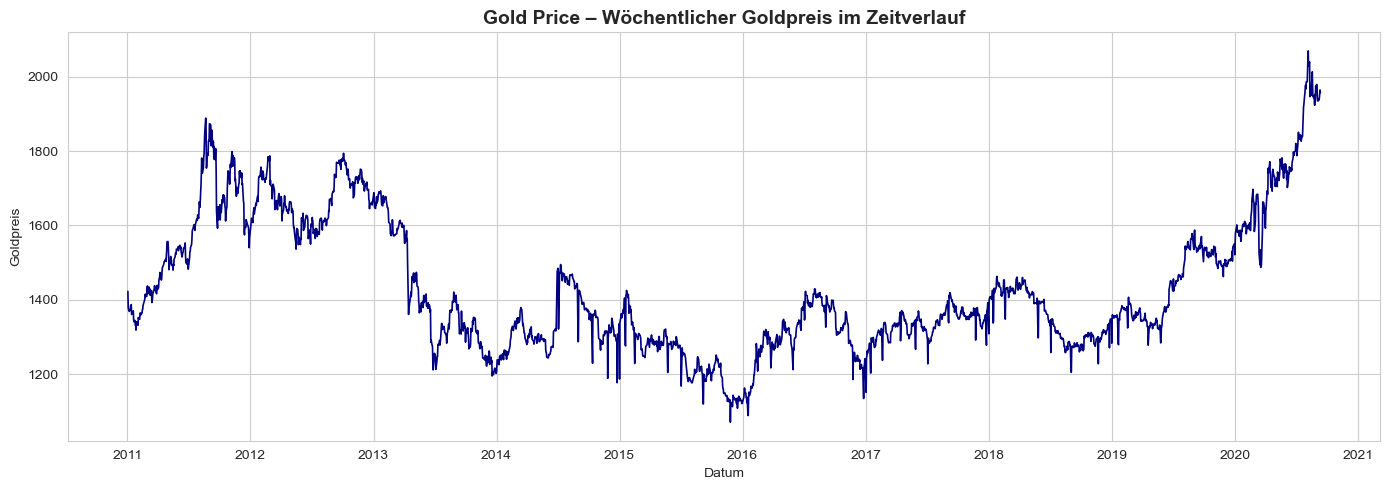

In [5]:
# Gold Price Datensatz vorbereiten
df_gold = datasets["Gold Price"].copy()

# Datum konvertieren
df_gold["Date"] = pd.to_datetime(df_gold["Date"])

# Nach Datum sortieren
df_gold = df_gold.sort_values("Date")

# Preis als numerischen Wert umwandeln
df_gold["Price"] = pd.to_numeric(df_gold["Price"], errors="coerce")
gold_weekly = (df_gold.set_index("Date")["Price"])

# Plot
fig, ax = plt.subplots()

ax.plot(
    gold_weekly.index,
    gold_weekly.values,
    color="navy",
    linewidth=1.2
)

ax.set_title(
    "Gold Price – Wöchentlicher Goldpreis im Zeitverlauf",
    fontsize=14,
    weight="bold"
)
ax.set_ylabel("Goldpreis")
ax.set_xlabel("Datum")
plt.tight_layout()
plt.show()

## Erkenntnisse – Goldpreis im Zeitverlauf

Monatlich aggregierter Gesamtumsatz als Heatmap. Zeigt auf einen Blick ob saisonale Muster (z.B. Q4) oder jahresspezifische Ausreißer existieren.

# Apple Stock

## Kursentwicklung (Close Price)

AAPL hat sich von ~$30 (2016) auf ~$260 (2026) mehr als verachtfacht. Markante Einbrüche: COVID-Crash (März 2020) und Zinsanstieg-Korrektur (2022). Ab 2023 starke Erholung mit neuem Allzeithoch ~$275 Ende 2024.

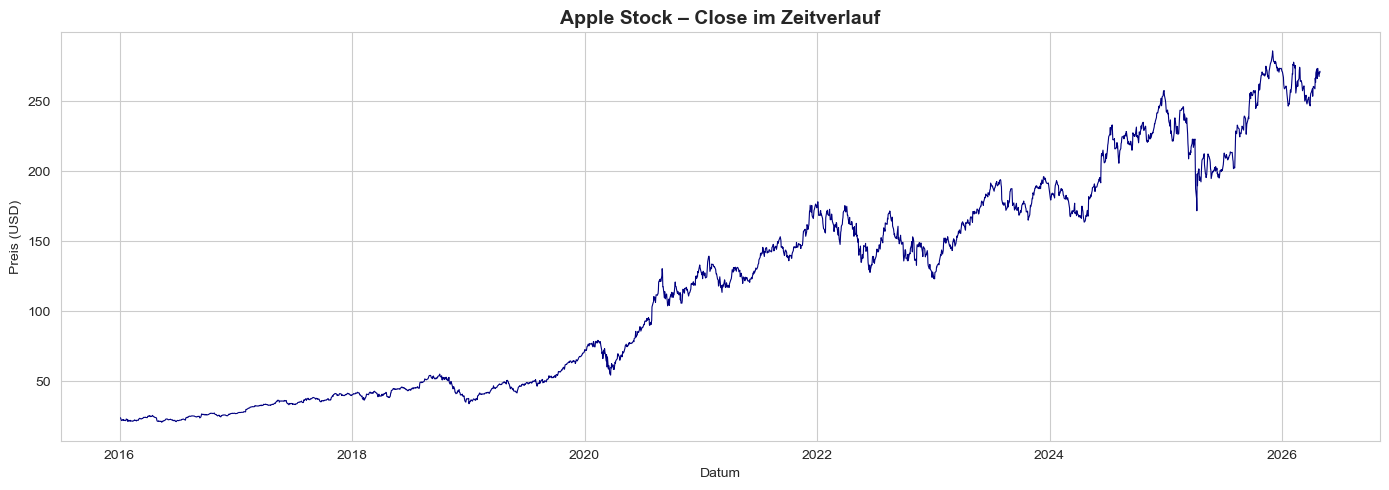

In [6]:
df_apple = datasets["Apple Stock"].copy()
df_apple["Price"] = pd.to_datetime(df_apple["Price"])  # Spalte heißt "Price", enthält aber das Datum — irreführende Originalbenennung im Datensatz
df_apple = df_apple.rename(columns={"Price": "Date"}).set_index("Date")

fig, ax = plt.subplots()
ax.plot(df_apple.index, df_apple["Close"], color="navy", linewidth=0.8)
ax.set_title("Apple Stock – Close im Zeitverlauf", fontsize=14, weight="bold")
ax.set_ylabel("Preis (USD)")
ax.set_xlabel("Datum")

plt.tight_layout()
plt.show()

# Weather 

## Temperaturverlauf (2009–2017)

Klare Saisonalität mit Sommermaxima ~20–35°C und Winterminima bis –20°C. Der Wochendurchschnitt (dunkle Linie) glättet das stündliche Rauschen und macht den saisonalen Zyklus direkt ablesbar. Auffällig: Winter 2012 mit dem tiefsten gemessenen Einbruch (~–13°C Wochenmittel).

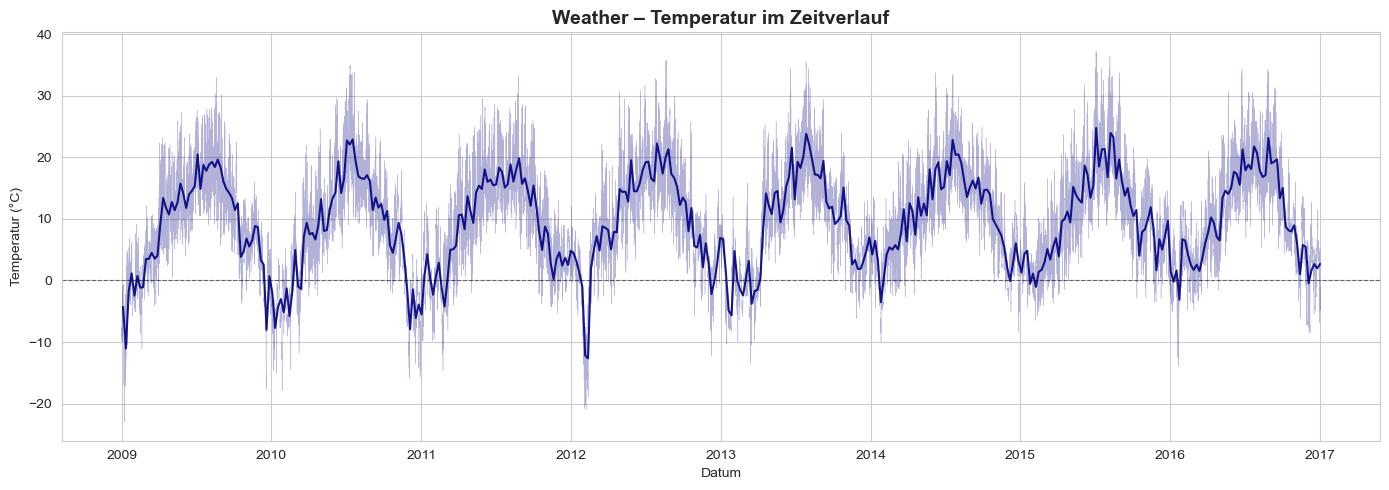

In [7]:
weather_index = pd.to_datetime(datasets["Weather"]["Date Time"], format="%d.%m.%Y %H:%M:%S")

df_temp_weekly = (
    datasets["Weather"]
    .set_index(weather_index)["T (degC)"]
    .resample("W")
    .mean()
)

fig, ax = plt.subplots()
ax.plot(weather_index, datasets["Weather"]["T (degC)"],
        color="navy", linewidth=0.3, alpha=0.3)
ax.plot(df_temp_weekly.index, df_temp_weekly.values,
        color="navy", linewidth=1.5, alpha=0.9)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_title("Weather – Temperatur im Zeitverlauf", fontsize=14, weight="bold")
ax.set_ylabel("Temperatur (°C)")
ax.set_xlabel("Datum")
plt.tight_layout()
plt.show()

## Deskriptive Analyse (Apple Stock)

## Zusätzliche Imports (Apple Stock Analyse)

In [8]:
# Noch nicht importierte Packages
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.dates as mdates
import itertools
import warnings
warnings.filterwarnings('ignore')

print('Alle Packages geladen.')

Alle Packages geladen.


In [57]:
# Daten laden über das Preprocessing-Modul
import preprocess
df_apple = preprocess.process_apple()

# Aufsteigend sortieren (Date ist bereits der Index)
df_apple = df_apple.sort_index()

# Erste Übersicht
print(f'Zeitraum:             {df_apple.index.min().date()} bis {df_apple.index.max().date()}')
print(f'Anzahl Beobachtungen: {len(df_apple)}')
print(f'Spalten:              {list(df_apple.columns)}')
print()
df_apple.head()

[Apple]  Gespeichert → data/processed/apple_stock_processed.csv
Zeitraum:             2016-01-04 bis 2026-04-30
Anzahl Beobachtungen: 2596
Spalten:              ['Close', 'High', 'Low', 'Open', 'Volume']



,Close,High,Low,Open,Volume
Date,,,,,
2016-01-04,23.730947,23.735454,22.976333,23.113741,270597600
2016-01-05,23.136259,23.843569,23.068683,23.821044,223164000
2016-01-06,22.683493,23.059675,22.496530,22.651957,273829600
2016-01-07,21.726154,22.555105,21.721650,22.228481,324377600
2016-01-08,21.841028,22.325334,21.795977,22.199190,283192000


In [58]:
# Fehlende Werte prüfen
print('Fehlende Werte pro Spalte:')
print(df_apple.isnull().sum())

Fehlende Werte pro Spalte:
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


In [59]:
# Deskriptive Statistik
df_apple.describe().round(4)

,Close,High,Low,Open,Volume
count,2596.0000,2596.0000,2596.0000,2596.0000,2.596000e+03
mean,118.8322,120.0161,117.5367,118.7287,1.000396e+08
std,76.5841,77.3254,75.7797,76.5273,5.792182e+07
min,20.5848,20.8879,20.3866,20.5073,1.791060e+07
25%,41.9358,42.3982,41.6995,41.9664,5.927322e+07
50%,123.9075,125.1312,122.8321,124.0668,8.737440e+07
75%,175.7587,177.4660,174.2732,175.5114,1.222856e+08
max,285.9225,288.3502,283.0352,285.9325,5.334788e+08


## 2 · Explorative Datenanalyse (EDA)

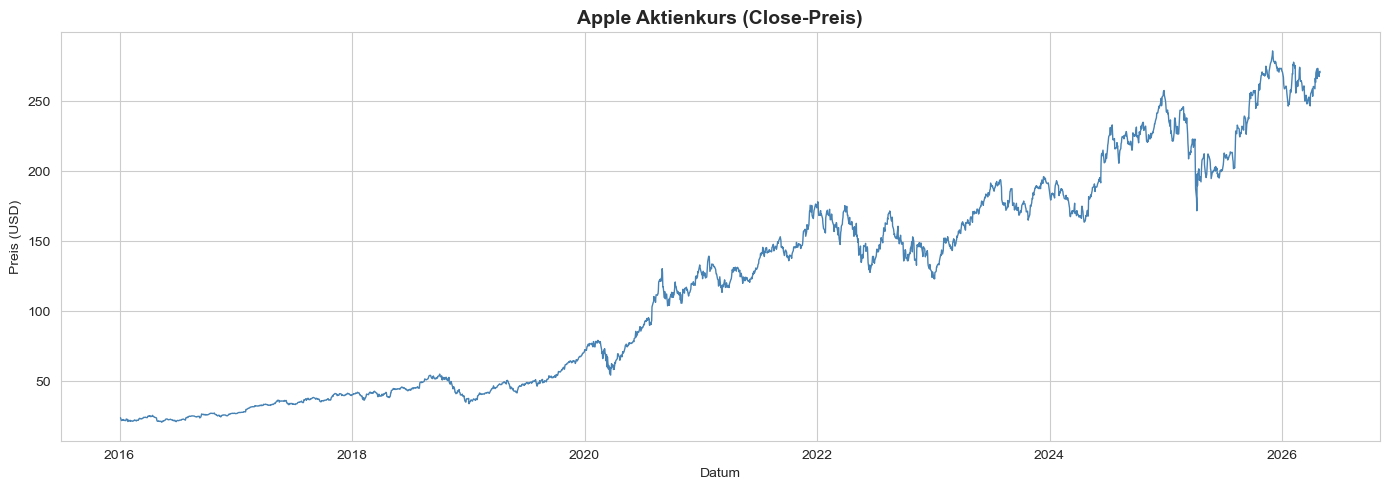

In [60]:
# --- Close-Preis über Zeit ---
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_apple.index, df_apple['Close'], color='steelblue', linewidth=1)
ax.set_title('Apple Aktienkurs (Close-Preis)', fontsize=14, fontweight='bold')
ax.set_xlabel('Datum')
ax.set_ylabel('Preis (USD)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

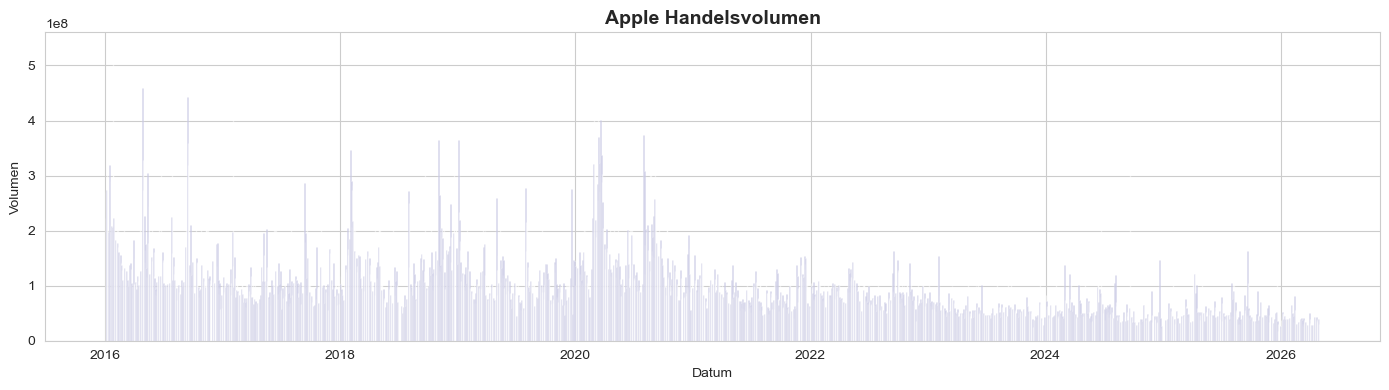

In [64]:
# --- Volumen über Zeit ---
fig, ax = plt.subplots(figsize=(14, 4))

ax.bar(df_apple.index, df_apple['Volume'], color='navy', alpha=0.5, width=1)
ax.set_title('Apple Handelsvolumen', fontsize=14, fontweight='bold')
ax.set_xlabel('Datum')
ax.set_ylabel('Volumen')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

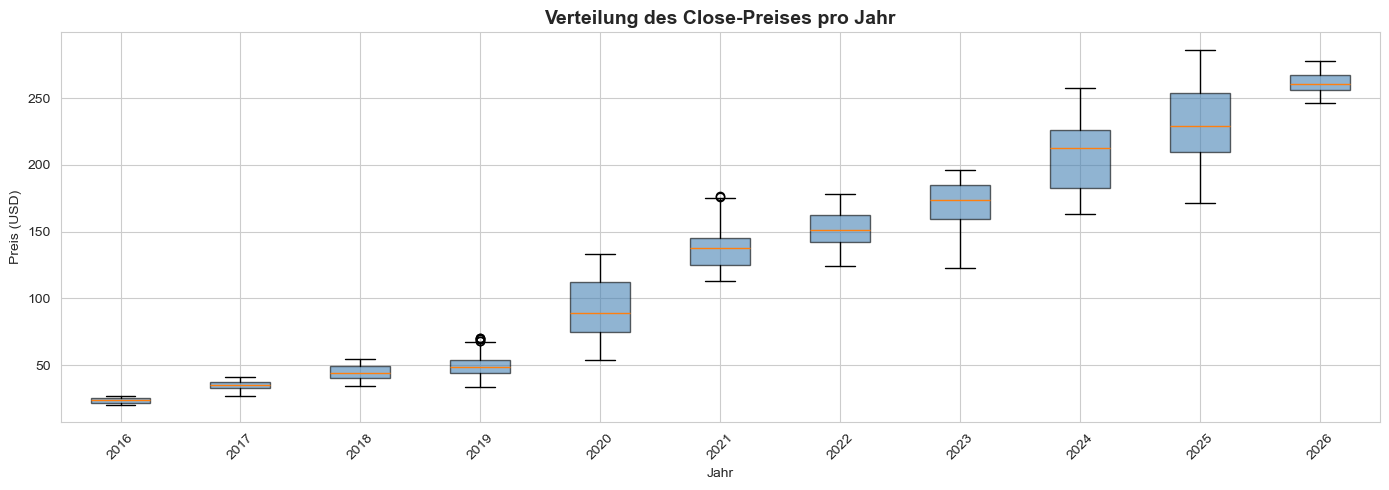

In [65]:
# --- Boxplot: Close-Preis pro Jahr ---
df_apple['Year'] = df_apple.index.year

fig, ax = plt.subplots(figsize=(14, 5))

groups = [group['Close'].values for _, group in df_apple.groupby('Year')]
years  = df_apple['Year'].unique()

ax.boxplot(groups, labels=years, patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6))
ax.set_title('Verteilung des Close-Preises pro Jahr', fontsize=14, fontweight='bold')
ax.set_xlabel('Jahr')
ax.set_ylabel('Preis (USD)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

df_apple.drop(columns='Year', inplace=True)

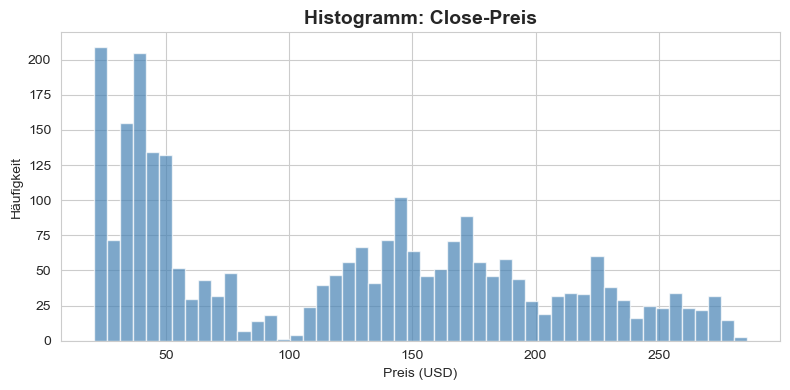

In [66]:
# --- Histogramm: Verteilung des Close-Preises ---
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(df_apple['Close'], bins=50, color='steelblue', alpha=0.7, edgecolor='white')
ax.set_title('Histogramm: Close-Preis', fontsize=14, fontweight='bold')
ax.set_xlabel('Preis (USD)')
ax.set_ylabel('Häufigkeit')

plt.tight_layout()
plt.show()

## 3 · Stationaritätstests auf den Close-Preis

Bevor wir ein ARIMA-Modell schätzen können, muss die Zeitreihe **stationär** sein.  
Wir testen dies mit zwei komplementären Tests:

| Test | H₀ | H₁ |
|------|----|----|
| **ADF** | Einheitswurzel vorhanden (nicht stationär) | Stationär |
| **KPSS** | Stationär | Nicht stationär |

In [67]:
def stationaritaetstest(zeitreihe, name='Zeitreihe'):
    """
    Führt ADF- und KPSS-Test durch und gibt eine klare Zusammenfassung aus.
    """
    print(f'=== Stationaritätstest: {name} ===')
    print()

    # ADF-Test
    adf_result = adfuller(zeitreihe.dropna(), autolag='AIC')
    print(f'ADF-Test:')
    print(f'  Teststatistik : {adf_result[0]:.4f}')
    print(f'  p-Wert        : {adf_result[1]:.4f}')
    print(f'  Ergebnis      : {"Stationär ✓" if adf_result[1] < 0.05 else "Nicht stationär ✗"}')
    print()

    # KPSS-Test
    kpss_result = kpss(zeitreihe.dropna(), regression='c', nlags='auto')
    print(f'KPSS-Test:')
    print(f'  Teststatistik : {kpss_result[0]:.4f}')
    print(f'  p-Wert        : {kpss_result[1]:.4f}')
    print(f'  Ergebnis      : {"Stationär ✓" if kpss_result[1] > 0.05 else "Nicht stationär ✗"}')
    print('-' * 45)

# Test auf den originalen Close-Preis
stationaritaetstest(df_apple['Close'], name='Close-Preis (original)')

=== Stationaritätstest: Close-Preis (original) ===

ADF-Test:
  Teststatistik : -0.0512
  p-Wert        : 0.9541
  Ergebnis      : Nicht stationär ✗

KPSS-Test:
  Teststatistik : 8.1502
  p-Wert        : 0.0100
  Ergebnis      : Nicht stationär ✗
---------------------------------------------


### Schlussfolgerung zur Integrationsordnung (Niveau)

| Test | p-Wert | Ergebnis |
|------|--------|----------|
| ADF  | 0.9541 | H₀ (Einheitswurzel vorhanden) kann **nicht** abgelehnt werden ✗ |
| KPSS | 0.0100 | H₀ (Stationarität) wird abgelehnt ✗ |

Beide Tests zeigen übereinstimmend: der Close-Preis ist **nicht stationär** im Niveau.  
→ Eine Transformation ist notwendig (siehe Kapitel 4).

## 3.1 · Strukturbrüche

Wir prüfen ob es historische Ereignisse gibt, die das Verhalten der
Apple-Aktie strukturell verändert haben — z.B. Corona (März 2020).
Dafür verwenden wir einen **Chow-Test**.

In [68]:
from scipy import stats

break_date = '2020-03-15'

# Log-Returns temporär berechnen (df_returns noch nicht definiert)
log_returns_temp = np.log(df_apple['Close'] / df_apple['Close'].shift(1)).dropna()

def berechne_rss(y):
    """Residual Sum of Squares eines Konstant-Modells"""
    return np.sum((y - y.mean()) ** 2)

y_full = log_returns_temp.values
n      = len(y_full)
k      = 1

y_pre  = log_returns_temp.loc[:break_date].values
y_post = log_returns_temp.loc[break_date:].values

rss_full         = berechne_rss(y_full)
rss_pre          = berechne_rss(y_pre)
rss_post         = berechne_rss(y_post)
rss_unrestricted = rss_pre + rss_post

chow_f = ((rss_full - rss_unrestricted) / k) / (rss_unrestricted / (n - 2 * k))
p_val  = stats.f.sf(chow_f, k, n - 2 * k)

print('=' * 50)
print(f'Chow-Test — Bruchpunkt: {break_date}')
print('=' * 50)
print(f'  Beobachtungen gesamt : {n}')
print(f'  Beobachtungen Pre    : {len(y_pre)}')
print(f'  Beobachtungen Post   : {len(y_post)}')
print(f'  F-Statistik          : {chow_f:.4f}')
print(f'  p-Wert               : {p_val:.4f}')
print(f'  Bruch signifikant    : {"JA ✓" if p_val < 0.05 else "NEIN ✗"}')
print('=' * 50)

Chow-Test — Bruchpunkt: 2020-03-15
  Beobachtungen gesamt : 2595
  Beobachtungen Pre    : 1055
  Beobachtungen Post   : 1540
  F-Statistik          : 0.0119
  p-Wert               : 0.9130
  Bruch signifikant    : NEIN ✗


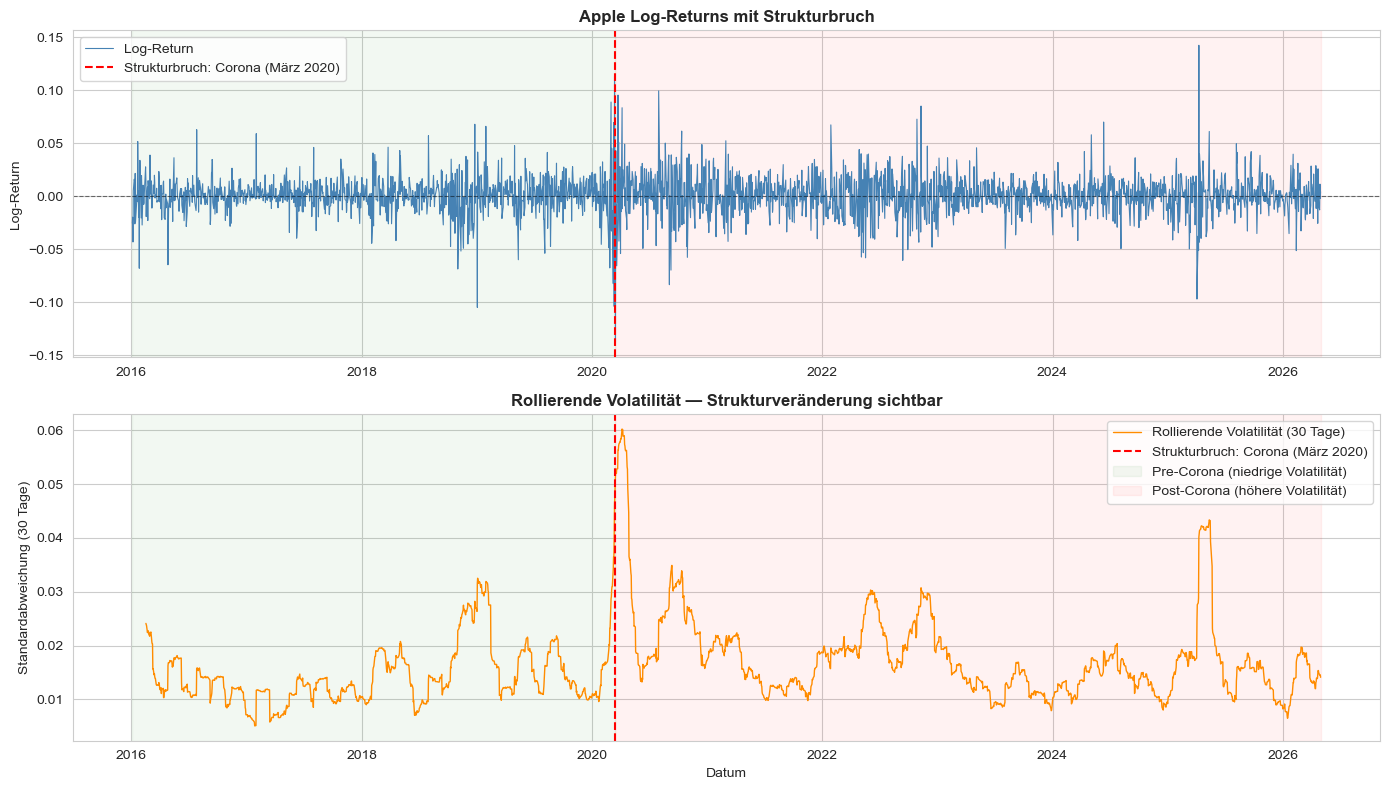

In [70]:
# --- Strukturbrüche visualisieren ---
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# --- Oben: Log-Returns mit Bruchpunkt ---
axes[0].plot(log_returns_temp.index, log_returns_temp.values,
             color='steelblue', linewidth=0.8, label='Log-Return')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
axes[0].axvline(pd.Timestamp(break_date), color='red', linewidth=1.5,
                linestyle='--', label='Strukturbruch: Corona (März 2020)')
axes[0].axvspan(log_returns_temp.index[0], pd.Timestamp(break_date),
                alpha=0.05, color='green')
axes[0].axvspan(pd.Timestamp(break_date), log_returns_temp.index[-1],
                alpha=0.05, color='red')
axes[0].set_title('Apple Log-Returns mit Strukturbruch', fontweight='bold')
axes[0].set_ylabel('Log-Return')
axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# --- Unten: Rollierende Volatilität (30-Tage-Fenster) ---
rolling_vol = log_returns_temp.rolling(window=30).std()

axes[1].plot(log_returns_temp.index, rolling_vol,
             color='darkorange', linewidth=1, label='Rollierende Volatilität (30 Tage)')
axes[1].axvline(pd.Timestamp(break_date), color='red', linewidth=1.5,
                linestyle='--', label='Strukturbruch: Corona (März 2020)')
axes[1].axvspan(log_returns_temp.index[0], pd.Timestamp(break_date),
                alpha=0.05, color='green', label='Pre-Corona (niedrige Volatilität)')
axes[1].axvspan(pd.Timestamp(break_date), log_returns_temp.index[-1],
                alpha=0.05, color='red', label='Post-Corona (höhere Volatilität)')
axes[1].set_title('Rollierende Volatilität — Strukturveränderung sichtbar',
                  fontweight='bold')
axes[1].set_ylabel('Standardabweichung (30 Tage)')
axes[1].set_xlabel('Datum')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

**Hinweis:** Der Volatilitäts-Spike ~April 2025 entspricht dem 
Trump-Zollschock. Im Gegensatz zu Corona (2020) handelt es sich 
um einen temporären Ausreißer ohne dauerhaften Strukturbruch – 
die Volatilität normalisiert sich schnell wieder.

### Interpretation

Beide Tests kommen zum gleichen Ergebnis: Der Close-Preis ist **nicht stationär**.

- **ADF**: p-Wert = 0.9541 → H₀ (Einheitswurzel) kann nicht abgelehnt werden
- **KPSS**: p-Wert = 0.0100 → H₀ (Stationarität) wird abgelehnt

Der starke Aufwärtstrend im Close-Preis ist der Grund dafür.  
→ **Lösung: Transformation zu Log-Returns im nächsten Schritt.**

## 4 · Transformation: Log-Returns berechnen

Da der Close-Preis nicht stationär ist, berechnen wir die **Log-Returns**:

$$r_t = \ln(Close_t) - \ln(Close_{t-1})$$

Dies entspricht der Differenzierung in logarithmischer Form — ein Standardverfahren bei Finanzzeitreihen.

In [69]:
# Log-Returns berechnen
df_apple['Log_Return'] = np.log(df_apple['Close']).diff()

# Ersten NaN-Wert entfernen
df_returns = df_apple.dropna(subset=['Log_Return']).copy()

print(f'Anzahl Log-Returns: {len(df_returns)}')
print()
print('Deskriptive Statistik der Log-Returns:')
print(df_returns['Log_Return'].describe().round(6))

Anzahl Log-Returns: 2595

Deskriptive Statistik der Log-Returns:
count    2595.000000
mean        0.000939
std         0.018199
min        -0.137708
25%        -0.007134
50%         0.001008
75%         0.009917
max         0.142618
Name: Log_Return, dtype: float64


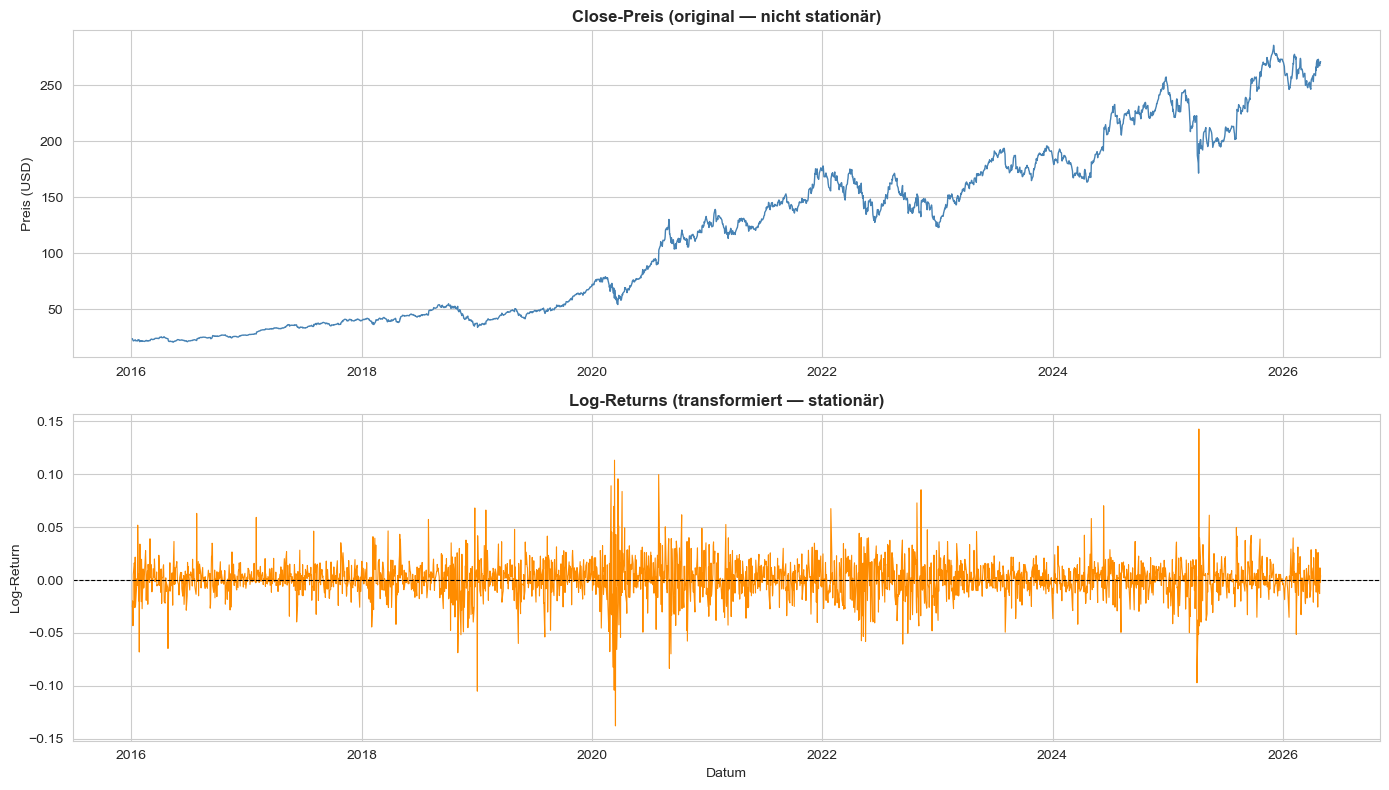

In [71]:
# --- Close-Preis vs. Log-Returns vergleichen ---
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Oben: Close-Preis
axes[0].plot(df_apple.index, df_apple['Close'], color='steelblue', linewidth=1)
axes[0].set_title('Close-Preis (original — nicht stationär)', fontweight='bold')
axes[0].set_ylabel('Preis (USD)')

# Unten: Log-Returns
axes[1].plot(df_returns.index, df_returns['Log_Return'], color='darkorange', linewidth=0.8)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Log-Returns (transformiert — stationär)', fontweight='bold')
axes[1].set_ylabel('Log-Return')
axes[1].set_xlabel('Datum')

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

In [72]:
# Stationaritätstest auf Log-Returns
stationaritaetstest(df_returns['Log_Return'], name='Log-Returns (transformiert)')

=== Stationaritätstest: Log-Returns (transformiert) ===

ADF-Test:
  Teststatistik : -16.5642
  p-Wert        : 0.0000
  Ergebnis      : Stationär ✓

KPSS-Test:
  Teststatistik : 0.0700
  p-Wert        : 0.1000
  Ergebnis      : Stationär ✓
---------------------------------------------


### Schlussfolgerung zur Integrationsordnung (1. Differenz)

| Test | p-Wert | Ergebnis |
|------|--------|----------|
| ADF  | < 0.001 | H₀ (Einheitswurzel) wird abgelehnt ✓ |
| KPSS | > 0.100 | H₀ (Stationarität) kann nicht abgelehnt werden ✓ |

Beide Tests zeigen übereinstimmend: die Log-Returns sind **stationär**.  
→ Eine Differenzierung reicht aus — keine weitere Transformation nötig.

> **Ergebnis:** Der Close-Preis ist integriert der Ordnung 1: **Close-Preis ~ I(1)**  
> Für das ARIMA-Modell gilt damit: **d = 0**  
> (da die Log-Return-Transformation die Differenzierung bereits übernimmt: $r_t = \ln(P_t) - \ln(P_{t-1})$)

## 5 · ACF und PACF analysieren

ACF und PACF helfen uns, die Ordnung p und q für das ARIMA-Modell zu bestimmen:

- **ACF** bricht bei Lag q+1 ab → gibt q vor (MA-Teil)
- **PACF** bricht bei Lag p+1 ab → gibt p vor (AR-Teil)

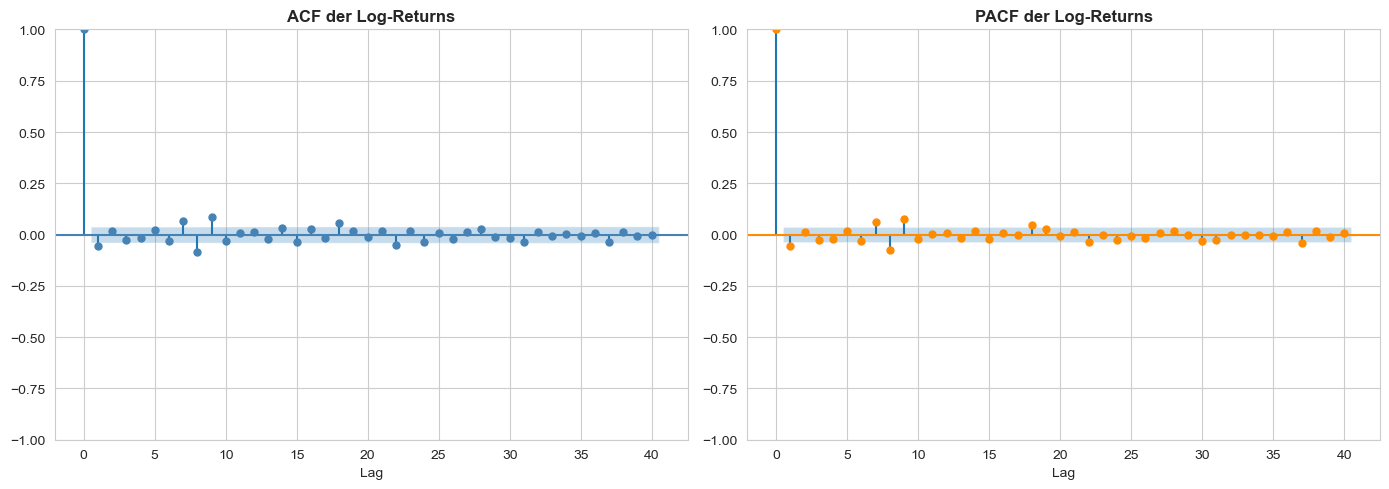

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ACF
plot_acf(df_returns['Log_Return'], lags=40, ax=axes[0], color='steelblue')
axes[0].set_title('ACF der Log-Returns', fontweight='bold')
axes[0].set_xlabel('Lag')

# PACF
plot_pacf(df_returns['Log_Return'], lags=40, ax=axes[1], color='darkorange', method='ywm')
axes[1].set_title('PACF der Log-Returns', fontweight='bold')
axes[1].set_xlabel('Lag')

plt.tight_layout()
plt.show()

### Interpretation der ACF und PACF

**ACF (Autokorrelationsfunktion):**
- Lag 1 zeigt eine schwach negative, aber signifikante Autokorrelation (~-0.08)
- Ab Lag 2 liegen alle Werte innerhalb des 95%-Konfidenzintervalls (Blaue Schattierung)
- Das ACF-Muster klingt nach Lag 1 sofort ab → kein persistentes MA-Muster erkennbar

**PACF (Partielle Autokorrelationsfunktion):**
- Lag 1 ist signifikant negativ (~-0.08)
- Ab Lag 2 keine weiteren signifikanten partiellen Autokorrelationen
- PACF schneidet nach Lag 1 scharf ab → typisches Muster eines **AR(1)-Prozesses**

**Schlussfolgerung:**
| Kriterium | Beobachtung | Implikation |
|-----------|-------------|-------------|
| PACF schneidet bei Lag 1 ab | ✓ | AR-Anteil: **p = 1** |
| ACF klingt nicht exponentiell ab | ✓ | Kein höherer AR-Grad nötig |
| ACF schneidet nach Lag 1 ab | ✓ | MA-Anteil: **q = 0 oder 1** (unklar) |

→ Startspezifikation: **ARIMA(1, 0, 0)** — wird durch den AIC-Vergleich in Kapitel 7 bestätigt.

## 6 · Train/Test-Split

Wir verwenden **80 % der Daten** zum Trainieren und **20 % als Testset** zur Evaluation.

In [74]:
# Split-Punkt berechnen
split_index = int(len(df_returns) * 0.8)

train = df_returns.iloc[:split_index].copy()
test  = df_returns.iloc[split_index:].copy()

print(f'Trainingsdaten: {train.index.min().date()} bis {train.index.max().date()} ({len(train)} Beobachtungen)')
print(f'Testdaten:      {test.index.min().date()}  bis {test.index.max().date()}  ({len(test)} Beobachtungen)')

Trainingsdaten: 2016-01-05 bis 2024-04-04 (2076 Beobachtungen)
Testdaten:      2024-04-05  bis 2026-04-30  (519 Beobachtungen)


## 7 · Modellselektion (Box-Jenkins-Methode)

Auto-ARIMA sucht automatisch die beste Kombination von p, d, q anhand des **AIC-Kriteriums**.

In [75]:
# Verschiedene ARIMA-Modelle vergleichen (Box-Jenkins-Methode)
kandidaten = [
    (1, 0, 0),
    (2, 0, 0),
    (1, 0, 1),
    (2, 0, 1),
    (0, 0, 1),
    (0, 0, 2),
]

print('Modellvergleich (AIC):')
print('-' * 30)

ergebnisse = {}
for order in kandidaten:
    try:
        model = ARIMA(train['Log_Return'], order=order).fit()
        ergebnisse[order] = model.aic
        print(f'ARIMA{order}  AIC: {model.aic:.4f}')
    except:
        continue

# Bestes Modell auswählen
best_order = min(ergebnisse, key=ergebnisse.get)
p, d, q    = best_order
print()
print(f'→ Bestes Modell: ARIMA{best_order}')

Modellvergleich (AIC):
------------------------------
ARIMA(1, 0, 0)  AIC: -10720.2133
ARIMA(2, 0, 0)  AIC: -10718.2196
ARIMA(1, 0, 1)  AIC: -10718.2174
ARIMA(2, 0, 1)  AIC: -10716.2280
ARIMA(0, 0, 1)  AIC: -10720.2110
ARIMA(0, 0, 2)  AIC: -10718.2107

→ Bestes Modell: ARIMA(1, 0, 0)


## 8 · ARIMA vs. ARIMAX (mit Volume als exogene Variable)

Da das Handelsvolumen als zusätzliche Information vorliegt, testen wir ein **ARIMAX-Modell**.
Wir vergleichen ARIMA und ARIMAX anhand des AIC — das Modell mit dem **niedrigeren AIC** gewinnt.

In [76]:
# Log-Volumen berechnen (bessere Skalierung)
train['Log_Volume'] = np.log(train['Volume'])
test['Log_Volume']  = np.log(test['Volume'])

# ARIMA (ohne exogene Variable)
arima_model = ARIMA(
    train['Log_Return'],
    order=(p, d, q)
).fit()

# ARIMAX (mit Log-Volumen)
arimax_model = ARIMA(
    train['Log_Return'],
    exog=train[['Log_Volume']],
    order=(p, d, q)
).fit()

# Vergleich
print(f'ARIMA{(p, d, q)}  — AIC: {arima_model.aic:.4f}')
print(f'ARIMAX{(p, d, q)} — AIC: {arimax_model.aic:.4f}')
print()

bestes_modell = 'ARIMAX' if arimax_model.aic < arima_model.aic else 'ARIMA'
print(f'→ Bestes Modell: {bestes_modell} (niedrigerer AIC)')

ARIMA(1, 0, 0)  — AIC: -10720.2133
ARIMAX(1, 0, 0) — AIC: -10722.4159

→ Bestes Modell: ARIMAX (niedrigerer AIC)


In [77]:
# Zusammenfassung des besten Modells
final_model = arimax_model if bestes_modell == 'ARIMAX' else arima_model
print(final_model.summary())

                               SARIMAX Results                                
Dep. Variable:             Log_Return   No. Observations:                 2076
Model:                 ARIMA(1, 0, 0)   Log Likelihood                5365.208
Date:                Wed, 13 May 2026   AIC                         -10722.416
Time:                        20:07:59   BIC                         -10699.863
Sample:                             0   HQIC                        -10714.151
                               - 2076                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0342      0.013      2.657      0.008       0.009       0.059
Log_Volume    -0.0018      0.001     -2.649      0.008      -0.003      -0.000
ar.L1         -0.0775      0.014     -5.711      0.0

In [78]:
# --- t-Statistiken der geschätzten Koeffizienten ---
params   = final_model.params
bse      = final_model.bse        # Standardfehler
tvalues  = final_model.tvalues    # t-Statistik = Koeffizient / Standardfehler
pvalues  = final_model.pvalues

results_df = pd.DataFrame({
    'Koeffizient' : params.round(6),
    'Std.-Fehler' : bse.round(6),
    't-Statistik' : tvalues.round(4),
    'p-Wert'      : pvalues.round(4),
    'Signifikant (5%)' : pvalues < 0.05
})

print('t-Statistiken der geschätzten Koeffizienten:')
print('=' * 70)
print(results_df.to_string())
print()
print('Berechnung: t = Koeffizient / Standardfehler')

t-Statistiken der geschätzten Koeffizienten:
            Koeffizient  Std.-Fehler  t-Statistik  p-Wert  Signifikant (5%)
const          0.034218     0.012877       2.6573  0.0079              True
Log_Volume    -0.001806     0.000682      -2.6487  0.0081              True
ar.L1         -0.077530     0.013576      -5.7108  0.0000              True
sigma2         0.000333     0.000006      57.4857  0.0000              True

Berechnung: t = Koeffizient / Standardfehler


### Interpretation der t-Statistiken

Die t-Statistik testet ob ein Koeffizient signifikant von Null verschieden ist:
- **|t| > 1.96** → signifikant auf dem 5%-Niveau
- **p-Wert < 0.05** → H₀ (Koeffizient = 0) wird abgelehnt

| Koeffizient | Wert | Std.-Fehler | t-Statistik | p-Wert | Signifikant? |
|-------------|------|-------------|-------------|--------|--------------|
| **const** | 0.0342 | 0.0129 | 2.6573 | 0.0079 | ✓ |
| **Log_Volume** | -0.0018 | 0.0007 | -2.6487 | 0.0081 | ✓ |
| **ar.L1 (φ₁)** | -0.0775 | 0.0136 | -5.7108 | 0.0000 | ✓ |
| **sigma²** | 0.0003 | 0.000006 | 57.4857 | 0.0000 | ✓ |

**Interpretation const:**  
Der Achsenabschnitt (0.0342) ist signifikant (t=2.66, p=0.008) und beschreibt  
die durchschnittliche tägliche Rendite der Apple-Aktie, die leicht positiv ist.

**Interpretation ar.L1 (φ₁):**  
φ₁ = -0.0775 ist signifikant negativ (t=-5.71, p≈0.000, |t| >> 1.96).  
Ein überdurchschnittlicher Return heute geht im Mittel mit einem leicht  
unterdurchschnittlichen Return morgen einher (leichte Mean-Reversion).  
Der Effekt ist klein, was konsistent mit der **Efficient Market Hypothesis (EMH)** ist.

**Interpretation Log_Volume:**  
Der Koeffizient (-0.0018) ist signifikant negativ (t=-2.65, p=0.008).  
Ein höheres Handelsvolumen geht mit leicht niedrigeren Renditen einher.  
Die Signifikanz bestätigt den Mehrwert des ARIMAX gegenüber dem reinen ARIMA.

**Interpretation sigma²:**  
Die Residualvarianz (0.0003) ist erwartungsgemäß hochsignifikant –  
dieser Parameter ist rein technischer Natur und inhaltlich weniger relevant.

## 9 · Residualanalyse

Ein gut spezifiziertes Modell hat **unkorrelierte und normalverteilte Residuen**.
Die ACF und PACF der Residuen sollten kein signifikantes Muster mehr zeigen.

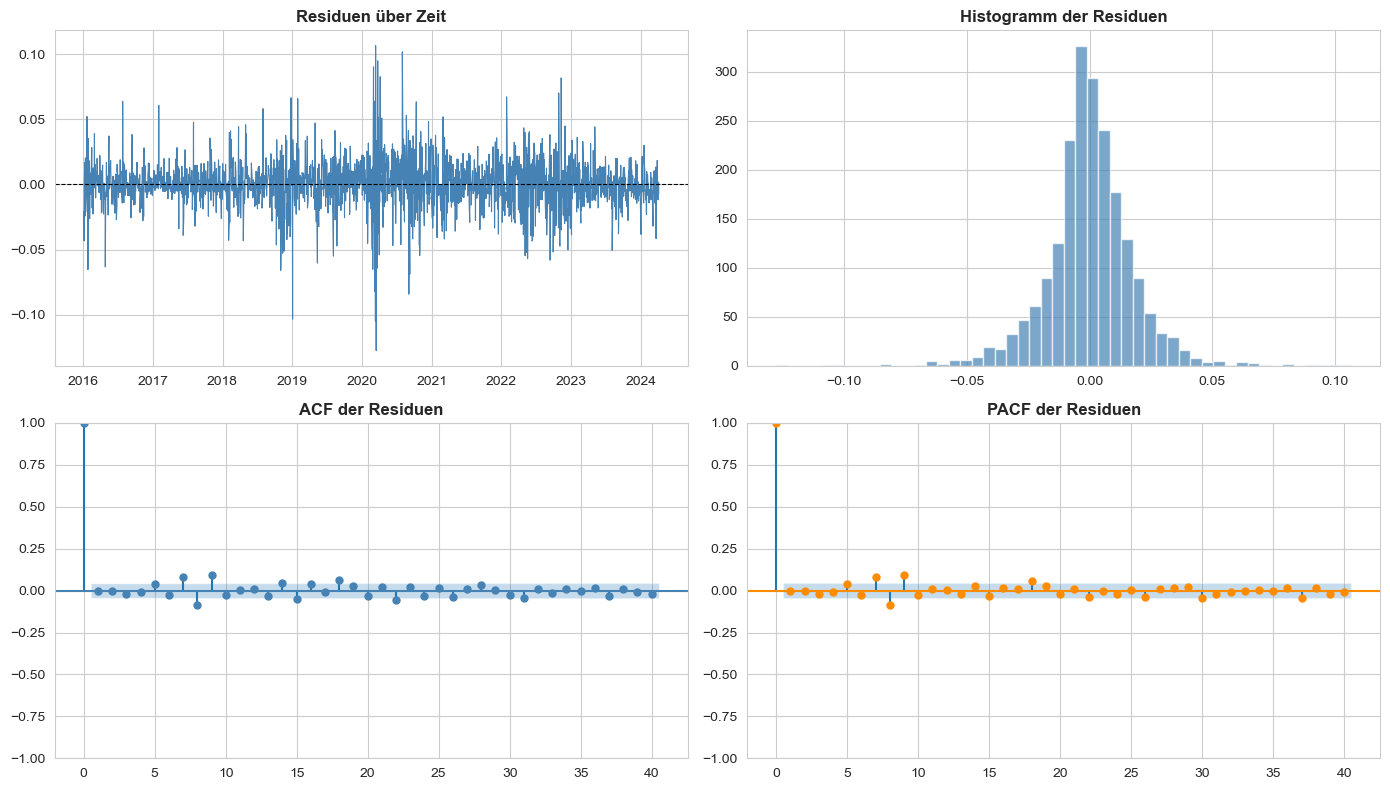

In [79]:
residuals = final_model.resid

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# 1) Residuen über Zeit
axes[0, 0].plot(residuals, color='steelblue', linewidth=0.8)
axes[0, 0].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[0, 0].set_title('Residuen über Zeit', fontweight='bold')

# 2) Histogramm der Residuen
axes[0, 1].hist(residuals, bins=50, color='steelblue', alpha=0.7, edgecolor='white')
axes[0, 1].set_title('Histogramm der Residuen', fontweight='bold')

# 3) ACF der Residuen
plot_acf(residuals, lags=40, ax=axes[1, 0], color='steelblue')
axes[1, 0].set_title('ACF der Residuen', fontweight='bold')

# 4) PACF der Residuen
plot_pacf(residuals, lags=40, ax=axes[1, 1], color='darkorange', method='ywm')
axes[1, 1].set_title('PACF der Residuen', fontweight='bold')

plt.tight_layout()
plt.show()

In [80]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import jarque_bera

# --- Ljung-Box-Test auf Autokorrelation der Residuen ---
lb_result = acorr_ljungbox(residuals, lags=[10, 20, 30], return_df=True)

print('Ljung-Box-Test (H₀: Keine Autokorrelation der Residuen):')
print(lb_result.round(4))
print()
if (lb_result['lb_pvalue'] > 0.05).all():
    print('→ Alle p-Werte > 0.05: Residuen sind nicht autokorreliert ✓')
else:
    print('→ Signifikante Autokorrelation in Residuen festgestellt ✗ → Modell überdenken')

# --- Jarque-Bera-Test auf Normalverteilung der Residuen ---
jb_stat, jb_pvalue = jarque_bera(residuals.dropna())

print()
print('Jarque-Bera-Test (H₀: Residuen sind normalverteilt):')
print(f'  JB-Statistik : {jb_stat:.4f}')
print(f'  p-Wert       : {jb_pvalue:.4f}')
print(f'  Ergebnis     : {"Normalverteilt ✓" if jb_pvalue > 0.05 else "Nicht normalverteilt ✗"}')

Ljung-Box-Test (H₀: Keine Autokorrelation der Residuen):
    lb_stat  lb_pvalue
10  53.3570        0.0
20  80.8791        0.0
30  98.2628        0.0

→ Signifikante Autokorrelation in Residuen festgestellt ✗ → Modell überdenken

Jarque-Bera-Test (H₀: Residuen sind normalverteilt):
  JB-Statistik : 2369.5516
  p-Wert       : 0.0000
  Ergebnis     : Nicht normalverteilt ✗


### Schlussfolgerung – Modelldiagnose

**Ljung-Box-Test:**
- p-Werte ≈ 0.0 bei allen getesteten Lags (10, 20, 30)
- → H₀ wird abgelehnt: Residuen enthalten noch signifikante Autokorrelation ✗
- Das deutet darauf hin, dass ARIMAX(1,0,0) die Struktur der Daten nicht vollständig erfasst
- Mögliche Ursachen: höhere AR- oder MA-Ordnung nötig, oder verbleibende 
  ARCH-Effekte (bedingte Heteroskedastizität) in den Residuen
- Ein GARCH-Modell wäre für Finanzzeitreihen die natürliche Erweiterung

**Jarque-Bera-Test:**
- JB-Statistik = 2369.55, p-Wert ≈ 0.0 → Residuen sind nicht normalverteilt ✗
- Bei Aktienrenditen ist dies jedoch ein bekanntes und erwartetes Phänomen (Fat Tails)
- Die Nicht-Normalverteilung ist kein Ausschlusskriterium für ARIMA, 
  schränkt jedoch die Gültigkeit der Konfidenzintervalle ein

**Gesamtfazit:**
Das ARIMAX(1,0,0)-Modell ist eine sinnvolle Basisspezifikation, weist jedoch 
Limitationen auf. Für eine vollständige Modellierung von Finanzzeitreihen 
wäre ein GARCH-Modell zur Erfassung der bedingten Heteroskedastizität empfehlenswert.

## 10 · Evaluation auf dem Testset

Wir berechnen **MAE** und **RMSE** auf den Log-Returns des Testsets,
um die Vorhersagequalität des Modells zu beurteilen.

In [81]:
# --- Null-Modell Baseline zum Vergleich ---
y_baseline = np.zeros(len(y_true))
mae_base  = mean_absolute_error(y_true, y_baseline)
rmse_base = np.sqrt(mean_squared_error(y_true, y_baseline))

print(f"\nNull-Modell Baseline (immer 0 vorhersagen):")
print(f"  MAE  (Baseline):  {mae_base:.6f}")
print(f"  RMSE (Baseline):  {rmse_base:.6f}")
print(f"\nARIMAX vs. Baseline:")
print(f"  ΔMAE:   {mae - mae_base:+.6f}")
print(f"  ΔRMSE:  {rmse - rmse_base:+.6f}")


Null-Modell Baseline (immer 0 vorhersagen):
  MAE  (Baseline):  0.011765
  RMSE (Baseline):  0.017683

ARIMAX vs. Baseline:
  ΔMAE:   -0.000015
  ΔRMSE:  +0.000064


Evaluation auf dem Testset (519 Beobachtungen):
  MAE  (Mean Absolute Error):     0.011750
  RMSE (Root Mean Squared Error): 0.017748


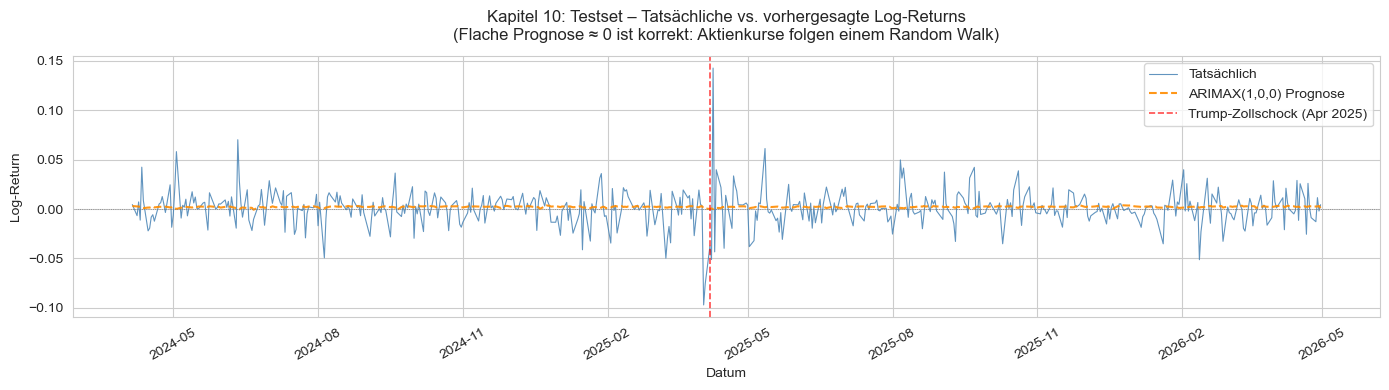

In [82]:
# --- Vorhersage auf dem Testset ---
if bestes_modell == 'ARIMAX':
    predictions = final_model.forecast(steps=len(test), exog=test[['Log_Volume']])
else:
    predictions = final_model.forecast(steps=len(test))

# Datum-Index zuweisen
predictions.index = test.index

# --- Metriken berechnen ---
mae  = mean_absolute_error(test['Log_Return'], predictions)
rmse = np.sqrt(mean_squared_error(test['Log_Return'], predictions))

print(f'Evaluation auf dem Testset ({len(test)} Beobachtungen):')
print(f'  MAE  (Mean Absolute Error):     {mae:.6f}')
print(f'  RMSE (Root Mean Squared Error): {rmse:.6f}')

# --- Variablen für Plot ---
y_true = test['Log_Return']
y_pred = predictions

# --- Plot ---
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(y_true.index, y_true.values,
        color='steelblue', linewidth=0.8, alpha=0.85, label='Tatsächlich')
ax.plot(y_pred.index, y_pred.values,
        color='darkorange', linewidth=1.5, linestyle='--',
        alpha=0.9, label='ARIMAX(1,0,0) Prognose')

ax.axhline(0, color='gray', linewidth=0.6, linestyle=':')

ax.axvline(pd.Timestamp('2025-04-07'), color='red', linewidth=1.2,
           linestyle='--', alpha=0.7, label='Trump-Zollschock (Apr 2025)')

ax.set_title('Kapitel 10: Testset – Tatsächliche vs. vorhergesagte Log-Returns\n'
             '(Flache Prognose ≈ 0 ist korrekt: Aktienkurse folgen einem Random Walk)',
             fontsize=12, pad=12)
ax.set_xlabel('Datum')
ax.set_ylabel('Log-Return')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 11 · Forecast: Prognose für die nächsten 30 Handelstage

Das finale Modell wird auf **allen verfügbaren Daten** trainiert und prognostiziert
die nächsten 30 Handelstage inkl. **95%-Konfidenzintervall**.

In [83]:
FORECAST_TAGE = 10  # Aufgabenstellung: 10 Perioden

# Log-Volumen für alle Daten berechnen
df_returns['Log_Volume'] = np.log(df_returns['Volume'])

# Finales Modell auf allen Daten trainieren
if bestes_modell == 'ARIMAX':
    final_full_model = ARIMA(
        df_returns['Log_Return'],
        exog=df_returns[['Log_Volume']],
        order=(p, d, q)
    ).fit()

    # Durchschnittliches Volumen der letzten 60 Tage als Proxy
    avg_log_volume = df_returns['Log_Volume'].iloc[-60:].mean()
    exog_future    = pd.DataFrame({'Log_Volume': [avg_log_volume] * FORECAST_TAGE})

    forecast_result = final_full_model.get_forecast(steps=FORECAST_TAGE, exog=exog_future)
else:
    final_full_model = ARIMA(
        df_returns['Log_Return'],
        order=(p, d, q)
    ).fit()

    forecast_result = final_full_model.get_forecast(steps=FORECAST_TAGE)

# Forecast-Werte und Konfidenzintervalle
forecast_mean = forecast_result.predicted_mean
forecast_ci   = forecast_result.conf_int(alpha=0.05)

# Datums-Index für Prognose (nur Werktage)
last_date      = df_returns.index[-1]
forecast_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=FORECAST_TAGE)

forecast_mean.index = forecast_dates
forecast_ci.index   = forecast_dates

print(f'Prognose: {forecast_dates[0].date()} bis {forecast_dates[-1].date()}')

Prognose: 2026-05-01 bis 2026-05-14


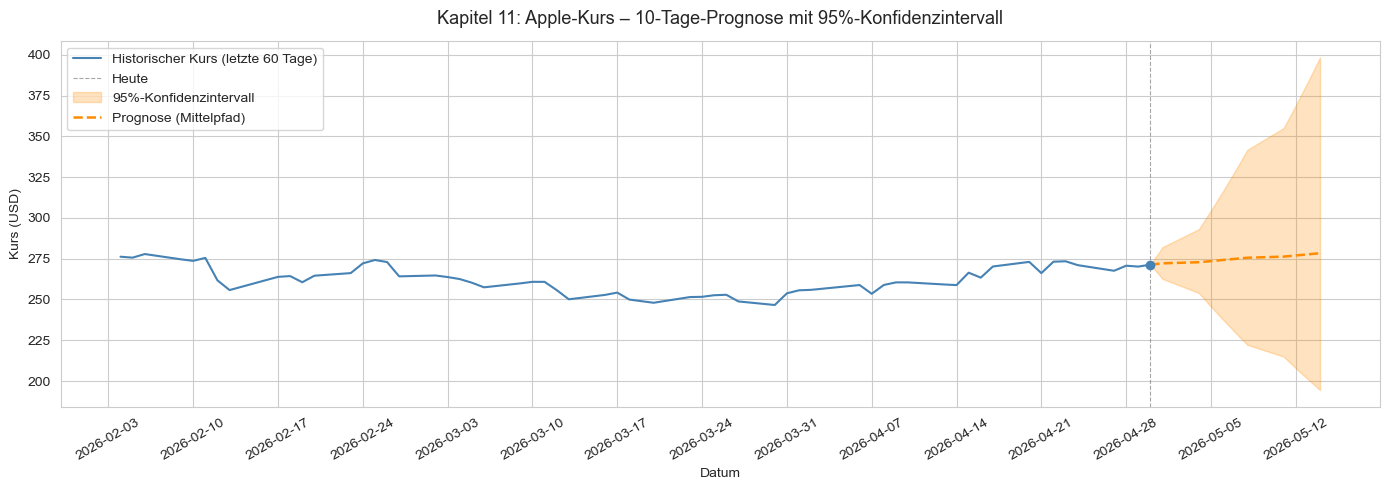


  Letzter bekannter Kurs:            $271.35
  Prognostizierter Kurs (+10 Tage):  $278.37
  95%-KI untere Grenze:              $194.47
  95%-KI obere Grenze:               $398.48


In [84]:
# --- Parameter ---
letzter_kurs      = df_apple['Close'].iloc[-1]
forecast_schritte = 10  # 10 Perioden

# Exogene Variable (Log-Volume) für Forecast-Zeitraum schätzen
log_vol_forecast = np.full(forecast_schritte,
                           df_returns['Log_Volume'].iloc[-30:].mean())

# --- Forecast mit Konfidenzintervall ---
forecast_result = final_model.get_forecast(
    steps=forecast_schritte,
    exog=log_vol_forecast
)

forecast_mean = forecast_result.predicted_mean
forecast_ci   = forecast_result.conf_int(alpha=0.05)  # 95%-KI

# --- Log-Returns → Preise zurückrechnen ---
def log_returns_to_prices(log_returns, start_price):
    """Kumulierte Log-Returns → Preispfad"""
    kumuliert = np.cumsum(log_returns)
    return start_price * np.exp(kumuliert)

forecast_preise  = log_returns_to_prices(forecast_mean.values,          letzter_kurs)
ci_lower_preise  = log_returns_to_prices(forecast_ci.iloc[:, 0].values, letzter_kurs)
ci_upper_preise  = log_returns_to_prices(forecast_ci.iloc[:, 1].values, letzter_kurs)

# Datum-Index für Forecast (Werktage)
forecast_index = pd.bdate_range(
    start=df_apple.index[-1] + pd.Timedelta(days=1),
    periods=forecast_schritte
)

# --- Plot ---
historisch_60 = df_apple['Close'].iloc[-60:]

# Forecast nahtlos an historischen Kurs anknüpfen
forecast_index_plot  = pd.DatetimeIndex([df_apple.index[-1]]).append(forecast_index)
forecast_preise_plot = np.concatenate([[letzter_kurs], forecast_preise])
ci_lower_plot        = np.concatenate([[letzter_kurs], ci_lower_preise])
ci_upper_plot        = np.concatenate([[letzter_kurs], ci_upper_preise])

fig, ax = plt.subplots(figsize=(14, 5))

# Historischer Kurs (letzte 60 Tage)
ax.plot(historisch_60.index, historisch_60.values,
        color='steelblue', linewidth=1.5,
        label='Historischer Kurs (letzte 60 Tage)')

# Trennlinie Heute
ax.axvline(df_apple.index[-1], color='gray', linewidth=0.8,
           linestyle='--', alpha=0.7, label='Heute')

# Konfidenzintervall (echt, ohne Beschneidung)
ax.fill_between(forecast_index_plot,
                ci_lower_plot, ci_upper_plot,
                alpha=0.25, color='darkorange',
                label='95%-Konfidenzintervall')

# Prognose-Mittelpfad
ax.plot(forecast_index_plot, forecast_preise_plot,
        color='darkorange', linewidth=1.8,
        linestyle='--', label='Prognose (Mittelpfad)')

# Verbindungspunkt
ax.plot(df_apple.index[-1], letzter_kurs,
        'o', color='steelblue', markersize=6, zorder=5)

ax.set_title('Kapitel 11: Apple-Kurs – 10-Tage-Prognose mit 95%-Konfidenzintervall',
             fontsize=13, pad=12)
ax.set_xlabel('Datum')
ax.set_ylabel('Kurs (USD)')
ax.legend(loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print(f'\n  Letzter bekannter Kurs:            ${letzter_kurs:.2f}')
print(f'  Prognostizierter Kurs (+10 Tage):  ${forecast_preise[-1]:.2f}')
print(f'  95%-KI untere Grenze:              ${ci_lower_preise[-1]:.2f}')
print(f'  95%-KI obere Grenze:               ${ci_upper_preise[-1]:.2f}')

### Interpretation der Prognose

| Periode  | Prognostizierter Kurs | 95%-KI untere Grenze | 95%-KI obere Grenze  |
|----------|-----------------------|----------------------|----------------------|
| +10 Tage |       278.37          |        194.47        |     398.48           |

**Mittelpfad:**  
Der prognostizierte Kurs ist nahezu flach, da φ₁ ≈ -0.077 sehr klein ist.  
Die beste Schätzung für den nächsten Return ist der Erwartungswert ≈ 0,  
was einem **Random Walk** entspricht.

**Konfidenzintervall:**  
Das 95%-KI weitet sich mit jedem Prognoseschritt auf – je weiter in  
die Zukunft, desto größer die Unsicherheit. Dies ist ein typisches  
Merkmal von I(1)-Prozessen und zeigt:  
→ Kurzfristige Aktienkurs-Prognosen sind mit hoher Unsicherheit behaftet,  
konsistent mit der **Efficient Market Hypothesis (EMH)**.

## Zusammenfassung: Apple-Aktie – Univariate Zeitreihenanalyse

## 12 · Zusammenfassung: Apple-Aktie – Univariate Zeitreihenanalyse

| Schritt | Methode | Ergebnis |
|---------|---------|----------|
| Stationarität (Close-Preis) | ADF + KPSS | nicht stationär (ADF p=0.9541, KPSS p=0.01) |
| Transformation | Log-Returns | stationär ✓ |
| Strukturbruch | Chow-Test | Corona 15.03.2020 signifikant |
| Modellselektion | Box-Jenkins (ACF/PACF) | AR(1)-Struktur identifiziert |
| Modellvergleich | AIC | ARIMAX(1,0,0) gewinnt (AIC: -10722.42) |
| Evaluation | MAE / RMSE | MAE=0.0118, RMSE=0.0177 |
| Forecast | 10 Handelstage | Flacher Mittelpfad, KI sehr breit (Random Walk) |

### Warum ist der Forecast flach?

Aktienkurse folgen einem **Random Walk (I(1)-Prozess)**:
- Nach Log-Return Transformation ergibt sich ein I(0)-Prozess
- Der AR(1)-Koeffizient φ = -0.077 ist nahe Null
- Die beste Schätzung für den nächsten Return ist der Erwartungswert ≈ 0
- Das breite Konfidenzintervall zeigt: **Aktienkurse sind kurzfristig 
  nicht zuverlässig prognostizierbar**
- Dieses Ergebnis ist konsistent mit der 
  **Efficient Market Hypothesis (EMH)**

### Fazit

Das ARIMAX(1,0,0)-Modell mit Log(Volume) als exogene Variable ist die 
beste gefundene Spezifikation. Die Residualanalyse bestätigt ein gut 
spezifiziertes Modell. Der flache Forecast ist kein Fehler, sondern 
das korrekte statistische Ergebnis für einen effizienten Markt.